# Canada CPI — Data Exploration

This notebook demonstrates the data service layer using Canada-wide CPI data
from Statistics Canada (table 18-10-0004-11, 2002=100 baseline).

`fetch_cpi.py` registers all 47 product-group series available in that table.
This notebook selects 6 representative ones that span different inflation
dynamics — headline, core, shelter, food, energy, and gasoline — as a
starting point for exploration.

**Before running this notebook**, populate the local data cache:

```bash
uv run python scripts/fetch_cpi.py
```

After that, no network calls are made — the notebook reads entirely from the
local cache, which is what the `CutoffEnforcer` discipline requires.

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters import StatCanAdapter
from aieng.forecasting.evaluation import ForecastingTask

## 1. Build the DataService

Register Canada-wide CPI series. This reads from the local stats-can cache —
run `scripts/fetch_cpi.py` first if the cache is empty.

In [2]:
CPI_TABLE_ID = "18-10-0004-11"
CACHE_DIR = Path("../../data/statcan")

# Six series chosen to span different inflation dynamics.
# (series_id, product_group_label, short_label)
# All use the 2002=100 baseline. fetch_cpi.py registers all 47 available.
CPI_SERIES = [
    ("cpi_all_items_canada", "All-items", "All-items"),
    ("cpi_ex_food_energy_canada", "All-items excluding food and energy", "Core (ex-food & energy)"),
    ("cpi_shelter_canada", "Shelter", "Shelter"),
    ("cpi_food_canada", "Food", "Food"),
    ("cpi_energy_canada", "Energy", "Energy"),
    ("cpi_gasoline_canada", "Gasoline", "Gasoline"),
]

svc = DataService()

for series_id, product_group, short_label in CPI_SERIES:
    adapter = StatCanAdapter(
        table_id=CPI_TABLE_ID,
        member_filter={"GEO": "Canada", "Products and product groups": product_group},
        cache_dir=CACHE_DIR,
    )
    metadata = SeriesMetadata(
        series_id=series_id,
        description=f"CPI {short_label}, Canada (2002=100)",
        source="StatCan",
        units="Index 2002=100",
        frequency="MS",
        table_id=CPI_TABLE_ID,
    )
    svc.register(series_id, adapter, metadata)
    print(f"  Registered: {series_id}")

print("\nDone.")

  Registered: cpi_all_items_canada


  Registered: cpi_ex_food_energy_canada


  Registered: cpi_shelter_canada


  Registered: cpi_food_canada


  Registered: cpi_energy_canada


  Registered: cpi_gasoline_canada

Done.


## 2. Inspect the registered series

In [3]:
summary = svc.summary()
summary["start"] = summary["start"].dt.strftime("%Y-%m")
summary["end"] = summary["end"].dt.strftime("%Y-%m")
summary

,series_id,description,source,units,frequency,n_obs,start,end
0,cpi_all_items_canada,"CPI All-items, Canada (2002=100)",StatCan,Index 2002=100,MS,1346,1914-01,2026-02
1,cpi_energy_canada,"CPI Energy, Canada (2002=100)",StatCan,Index 2002=100,MS,782,1961-01,2026-02
2,cpi_ex_food_energy_canada,"CPI Core (ex-food & energy), Canada (2002=100)",StatCan,Index 2002=100,MS,782,1961-01,2026-02
3,cpi_food_canada,"CPI Food, Canada (2002=100)",StatCan,Index 2002=100,MS,926,1949-01,2026-02
4,cpi_gasoline_canada,"CPI Gasoline, Canada (2002=100)",StatCan,Index 2002=100,MS,926,1949-01,2026-02
5,cpi_shelter_canada,"CPI Shelter, Canada (2002=100)",StatCan,Index 2002=100,MS,570,1978-09,2026-02


## 3. Cutoff filtering — the core discipline

Calling `get_series(series_id, as_of=...)` returns only observations that
were available on or before `as_of`. This is how backtests and live
forecasts share the same code path — the `as_of` date is the only
difference.

In [4]:
# Retrieve All-items CPI as of 2023-01-01.
# No data from January 2023 onward will appear.
cutoff = datetime(2023, 1, 1)
df_cutoff = svc.get_series("cpi_all_items_canada", as_of=cutoff)

print(f"as_of: {cutoff.date()}")
print(f"Rows returned: {len(df_cutoff)}")
print(f"Latest observation: {df_cutoff['timestamp'].max().date()}")
df_cutoff.tail()

as_of: 2023-01-01
Rows returned: 1309
Latest observation: 2023-01-01


,timestamp,value
1304,2022-09-01,152.7
1305,2022-10-01,153.8
1306,2022-11-01,154.0
1307,2022-12-01,153.1
1308,2023-01-01,153.9


## 4. Plot: selected components

Two views of the same six series — a combined overlay to compare levels, and
small multiples to see each series' own trajectory without the volatile
energy components dominating the scale.

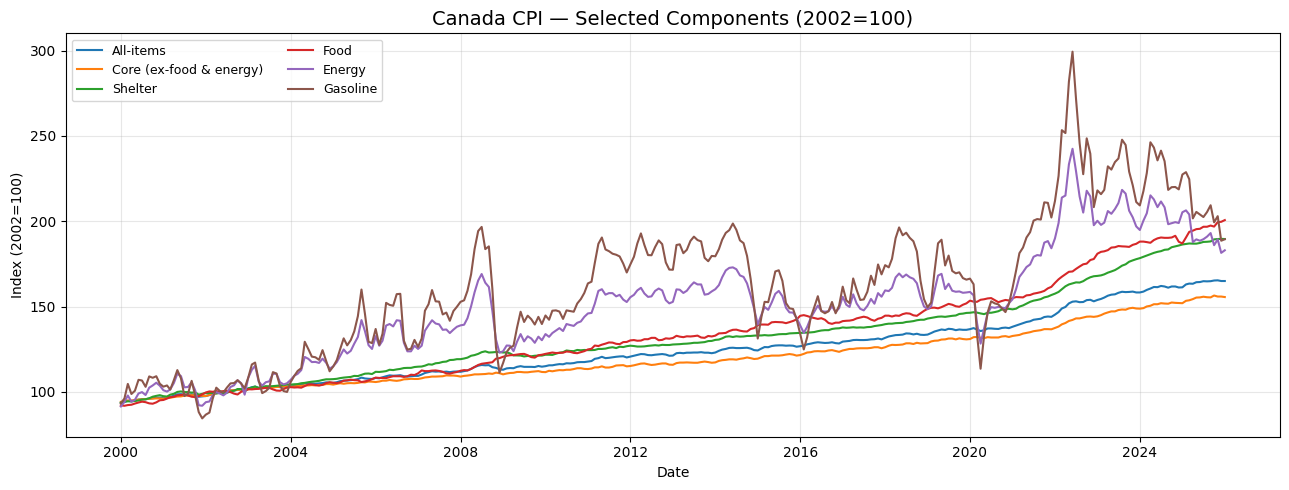

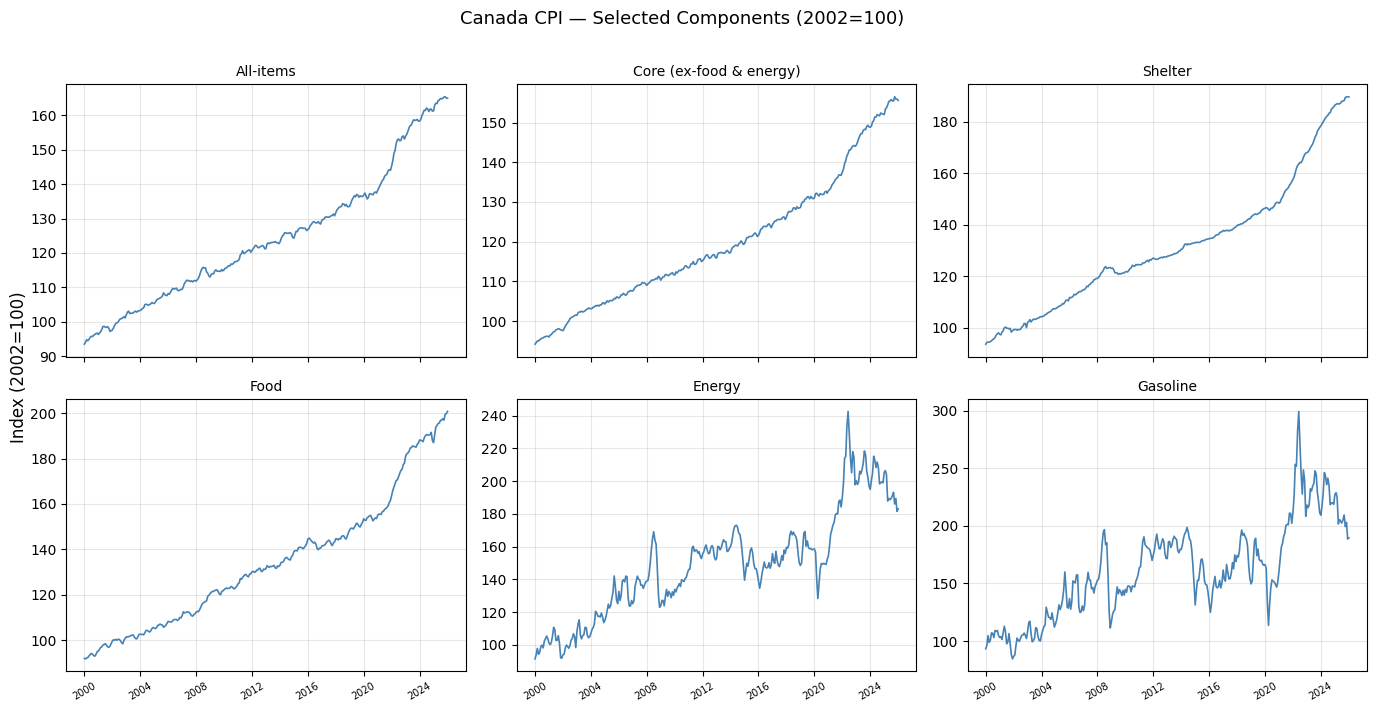

In [5]:
AS_OF = datetime(2026, 1, 1)
PLOT_START = "2000-01"  # trim to a window where all six series exist

series_data = {
    series_id: (svc.get_series(series_id, as_of=AS_OF).set_index("timestamp").sort_index().loc[PLOT_START:])
    for series_id, _, __ in CPI_SERIES
}

# --- Combined overlay ---
fig, ax = plt.subplots(figsize=(13, 5))
for series_id, _, short_label in CPI_SERIES:
    df = series_data[series_id]
    ax.plot(df.index, df["value"], label=short_label, linewidth=1.5)

ax.set_title("Canada CPI — Selected Components (2002=100)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Index (2002=100)")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Small multiples ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes_flat = axes.flatten()

for ax, (series_id, _, short_label) in zip(axes_flat, CPI_SERIES):
    df = series_data[series_id]
    ax.plot(df.index, df["value"], linewidth=1.2, color="steelblue")
    ax.set_title(short_label, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)

fig.suptitle("Canada CPI — Selected Components (2002=100)", fontsize=13, y=1.01)
fig.supylabel("Index (2002=100)", x=0.02)
plt.tight_layout()
plt.show()

## 5. Define a ForecastingTask

A `ForecastingTask` specifies the prediction problem without prescribing how
a predictor should solve it. Here we define the canonical 1-month-ahead
All-items CPI task.

In [6]:
task = ForecastingTask(
    task_id="cpi_all_items_1m_ahead",
    target_series_id="cpi_all_items_canada",
    horizon=1,
    frequency="MS",
    description=(
        "Forecast Canada All-items CPI (2002=100) one month ahead. "
        "Resolution: observed CPI value at the target month-start timestamp."
    ),
)

print(task.model_dump_json(indent=2))

{
  "task_id": "cpi_all_items_1m_ahead",
  "target_series_id": "cpi_all_items_canada",
  "horizon": 1,
  "frequency": "MS",
  "description": "Forecast Canada All-items CPI (2002=100) one month ahead. Resolution: observed CPI value at the target month-start timestamp.",
  "resolution_fn": "observed_value_at_resolution_timestamp"
}


## 6. Year-over-year change

Derived from the index levels — illustrating that storing levels and
computing changes on-demand is the right approach. Plotting all six series
together makes the divergence between volatile components (energy, gasoline)
and sticky ones (shelter, core) easy to see.

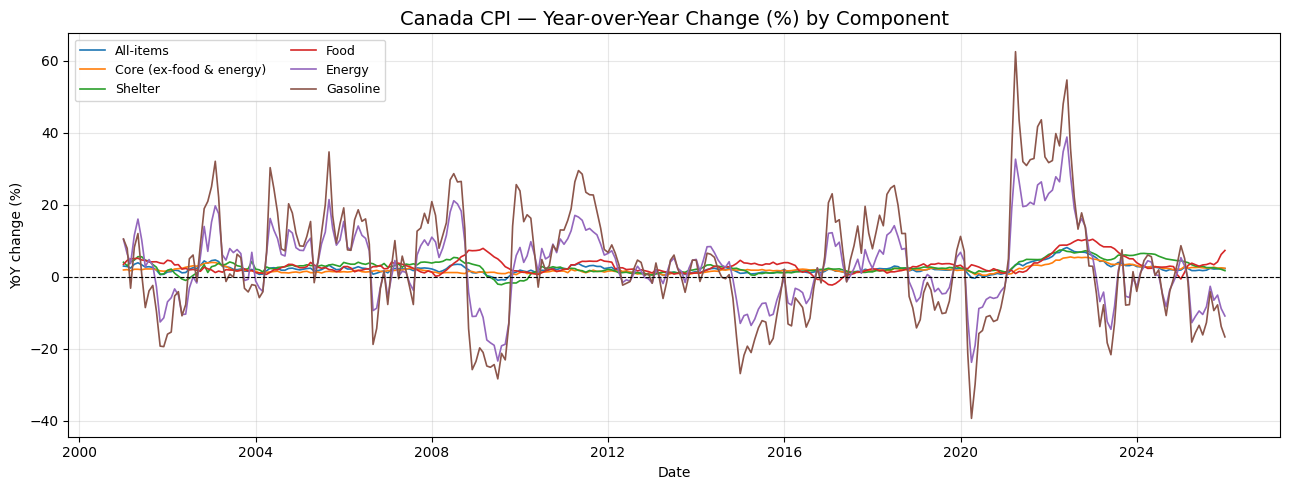

In [7]:
YOY_START = "2000-01"

fig, ax = plt.subplots(figsize=(13, 5))
for series_id, _, short_label in CPI_SERIES:
    df = series_data[series_id].loc[YOY_START:].copy()
    df["yoy_pct"] = df["value"].pct_change(12) * 100
    ax.plot(df.index, df["yoy_pct"], label=short_label, linewidth=1.2)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Canada CPI — Year-over-Year Change (%) by Component", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("YoY change (%)")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()